In [1]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df.shape

(284807, 31)

### Check fraud imbalance

In [3]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [4]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

### Class Distribution

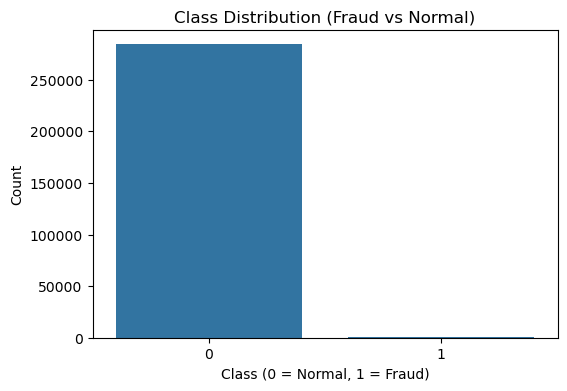

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (Fraud vs Normal)")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

### Class Distribution

The dataset is highly imbalanced, with fraudulent transactions representing a very small percentage (~0.17%) of total transactions.

This imbalance makes accuracy an unreliable metric, and requires the use of precision, recall, and F1-score for proper evaluation.

### Transaction Amount Distribution

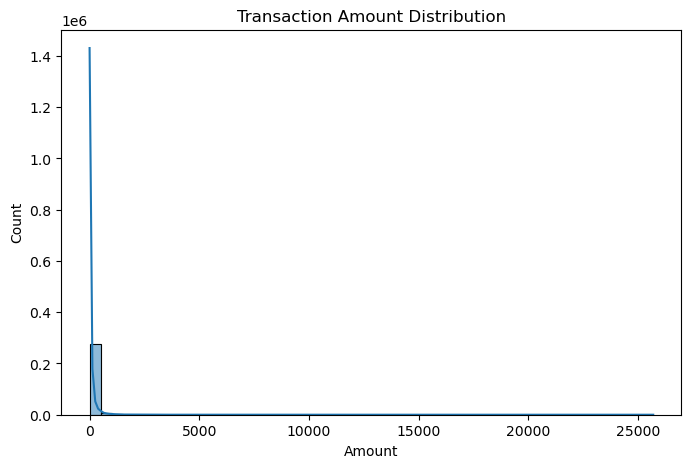

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

### Transaction Amount Distribution

Most transactions are of low value, with a long tail of high-value transactions. This suggests that fraud detection should consider both small and large transaction anomalies.

### Time Distribution

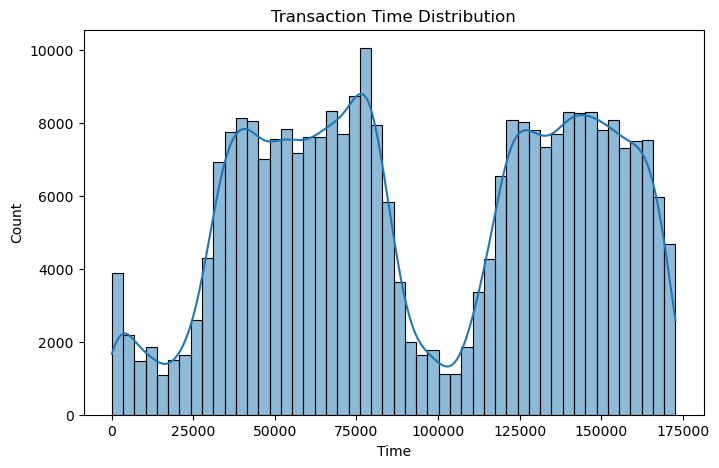

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Time'], bins=50, kde=True)
plt.title("Transaction Time Distribution")
plt.show()

### Time Distribution

Transaction times are spread across the dataset, indicating continuous activity. Temporal patterns may provide additional insights into fraudulent behaviour.

### Fraud vs Normal (Amount Comparison)

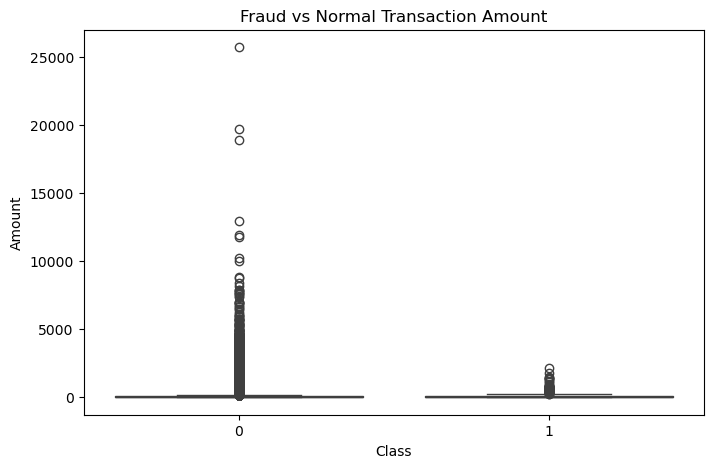

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Fraud vs Normal Transaction Amount")
plt.show()

### Fraud vs Normal Comparison

Fraudulent transactions tend to have different distributions compared to normal transactions, though overlap exists. This highlights the need for multi-feature models rather than relying on a single variable.

### Correlation Heatmap

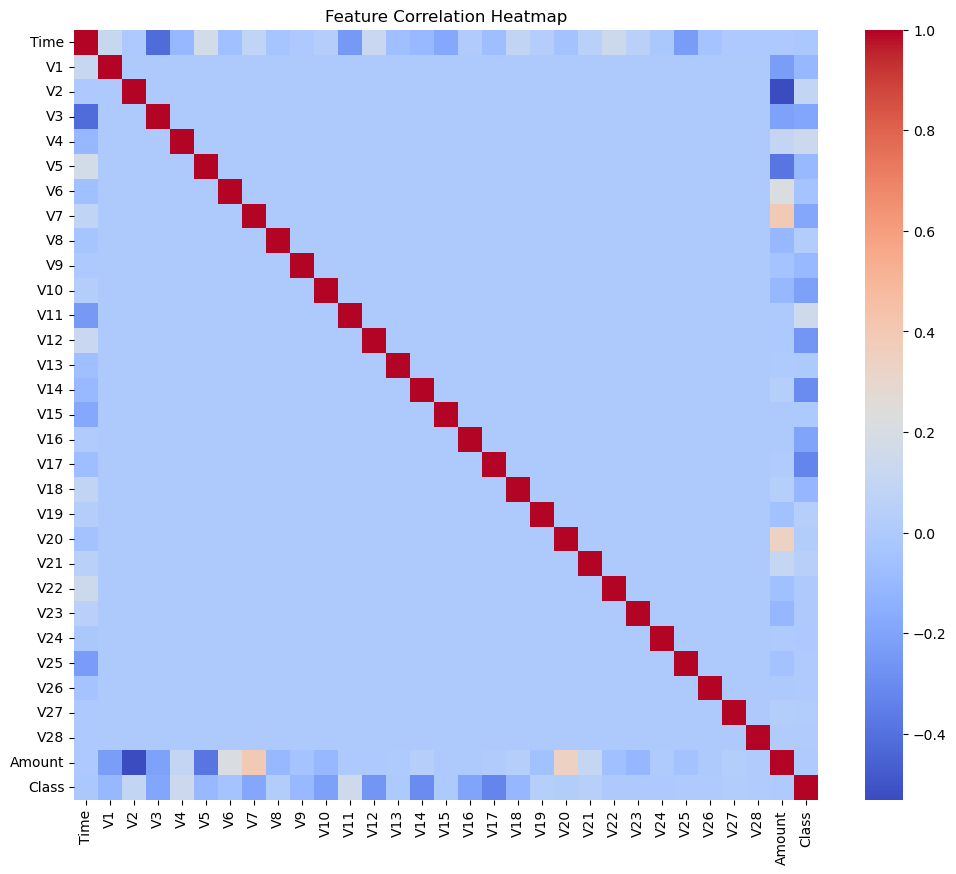

In [11]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

### Feature Correlation

Most features are weakly correlated due to PCA transformation. This indicates that models need to learn complex, non-linear relationships to detect fraud effectively.

### Top Features vs Fraud

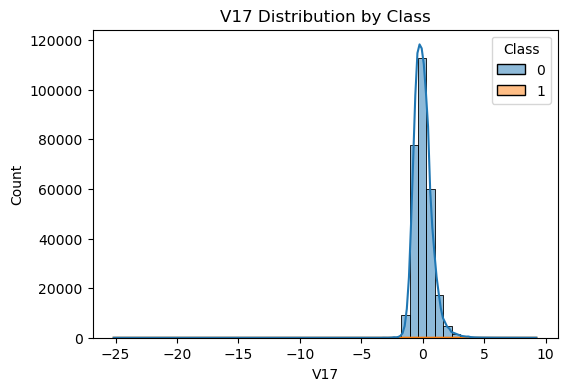

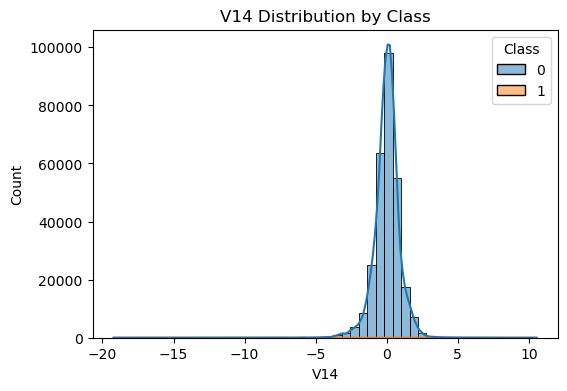

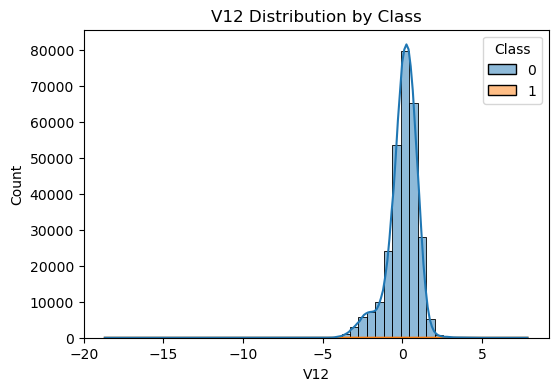

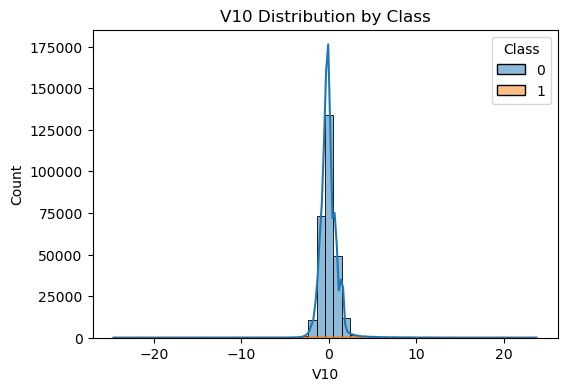

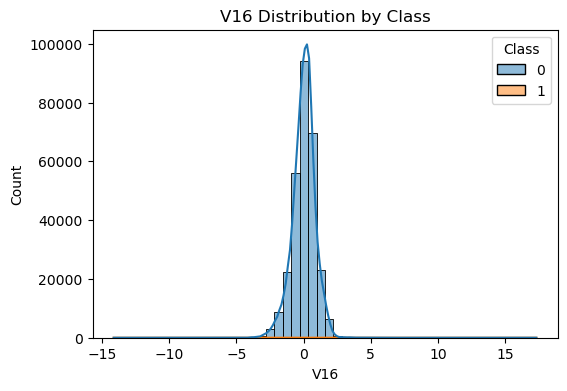

In [12]:
top_features = df.corr()['Class'].abs().sort_values(ascending=False)[1:6].index

for feature in top_features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=feature, hue='Class', bins=50, kde=True)
    plt.title(f"{feature} Distribution by Class")
    plt.show()

### Feature-Level Analysis

Certain features show stronger separation between fraudulent and normal transactions, indicating their importance in classification models.

### Train first XGBoost model

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

X = df.drop("Class", axis=1)
y = df["Class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=50,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))

[[56829    35]
 [   13    85]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.71      0.87      0.78        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962

F1 Score: 0.7798165137614679


## Save model

In [6]:
import joblib

joblib.dump(model, "../models/xgboost_fraud_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

## Key Insights

- The dataset is highly imbalanced (~0.17% fraud cases)
- Fraud detection requires recall-focused evaluation
- Transaction amount alone is not sufficient for classification
- PCA-transformed features require non-linear models like XGBoost
- Multiple features contribute to fraud detection patterns

These insights guide the selection of models and evaluation strategies.

## Isolation Forest — Unsupervised Anomaly Detection

In addition to the supervised XGBoost classifier, Isolation Forest is used as an unsupervised anomaly detection model. This helps identify unusual transaction patterns without relying directly on labelled fraud examples during training.

In [13]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.0017,   # close to actual fraud ratio
    random_state=42
)

iso_model.fit(X_train)

iso_pred_raw = iso_model.predict(X_test)

# Isolation Forest output:
#  1  = normal
# -1  = anomaly
# Convert to:
#  0 = normal
#  1 = fraud
iso_pred = [1 if pred == -1 else 0 for pred in iso_pred_raw]

print("Confusion Matrix:")
print(confusion_matrix(y_test, iso_pred))

print("\nClassification Report:")
print(classification_report(y_test, iso_pred))

iso_precision = precision_score(y_test, iso_pred)
iso_recall = recall_score(y_test, iso_pred)
iso_f1 = f1_score(y_test, iso_pred)

print("Isolation Forest Precision:", iso_precision)
print("Isolation Forest Recall:", iso_recall)
print("Isolation Forest F1 Score:", iso_f1)

Confusion Matrix:
[[56791    73]
 [   68    30]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.29      0.31      0.30        98

    accuracy                           1.00     56962
   macro avg       0.65      0.65      0.65     56962
weighted avg       1.00      1.00      1.00     56962

Isolation Forest Precision: 0.2912621359223301
Isolation Forest Recall: 0.30612244897959184
Isolation Forest F1 Score: 0.29850746268656714


### Isolation Forest Result Interpretation

Isolation Forest provides an anomaly-detection baseline for fraud detection. Since it does not learn from labelled fraud examples in the same way as XGBoost, its results are expected to be different.

This model is useful for comparing supervised fraud classification against unsupervised anomaly detection, which is common in real-world fraud monitoring systems where labelled fraud data may be limited.

## Model Comparison Insight

The supervised XGBoost model significantly outperforms the unsupervised Isolation Forest model in detecting fraudulent transactions.

While Isolation Forest is useful for anomaly detection, it struggles in highly imbalanced datasets where subtle fraud patterns require learned decision boundaries.

XGBoost, being a supervised model, leverages labelled data to achieve higher recall (0.87) and F1 score (0.78), making it more effective for fraud detection in this scenario.

This comparison highlights the importance of supervised learning in domains where labelled fraud data is available.

In [14]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.3/562.3 kB 2.2 MB/s eta 0:00:00-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 3.5 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.33.0 which is incompatible.


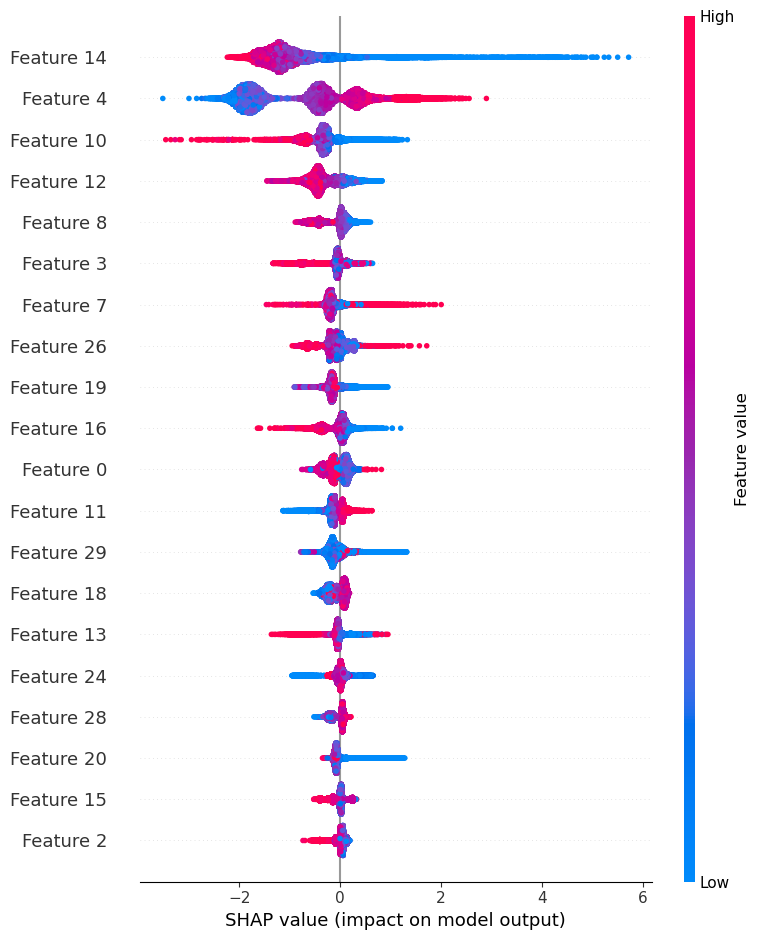

In [15]:
import shap

# create explainer
explainer = shap.TreeExplainer(model)

# compute SHAP values
shap_values = explainer.shap_values(X_test)

# summary plot
shap.summary_plot(shap_values, X_test)

## Model Explainability using SHAP

SHAP (SHapley Additive exPlanations) is used to interpret the XGBoost model by identifying the contribution of each feature to the prediction.

This helps in understanding which features influence fraud detection decisions, improving transparency and trust in the model.